<a href="https://colab.research.google.com/github/Ela4O4/CPE-311---Computational-Thinking-with-Python/blob/main/Hands_on_Activity_10_1_Data_Analysis_using_Python_Bautista.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Loading the datasets
df_gdp_growth = pd.read_csv('SDG 8.1.1.csv')
df_productivity = pd.read_csv('SDG 8.2.1.csv')
df_informal_female = pd.read_csv('SDG 8.3.1 Female.csv')
df_informal_male = pd.read_csv('SDG 8.3.1 Male.csv')

df_gdp_growth.head(10)

,category,Brunei Darussalam,Cambodia,Indonesia,Lao PDR,Malaysia,Myanmar,Philippines,Singapore,Thailand,Timor-Leste,Viet Nam
0,2016,3.52,7.0,3.72,5.40,3.0,NaN,5.40,2.4,2.9,NaN,5.52
1,2017,0.32,7.0,3.79,5.30,4.5,NaN,5.20,4.4,3.4,NaN,5.77
2,2018,1.10,7.5,3.93,4.80,3.7,5.5,4.70,3.0,3.8,NaN,6.23
3,2019,2.70,7.1,4.27,1.80,4.0,5.8,4.60,0.2,1.8,NaN,6.14
4,2020,0.10,-3.1,-3.03,0.40,5.2,2.3,-10.80,-3.5,-6.3,NaN,1.71
5,2021,2.50,3.0,2.52,-1.80,2.9,-6.7,4.33,14.4,1.3,NaN,1.59
6,2022,2.40,5.1,4.15,-22.09,8.6,NaN,6.26,0.7,2.2,NaN,7.48
7,2023,0.60,5.0,3.93,NaN,1.4,2.5,4.60,-3.0,1.7,NaN,4.19
8,2024,NaN,NaN,3.95,NaN,3.1,2.7,4.80,2.3,NaN,NaN,6.00


In [ ]:
# Dictionary
variables = {
    'Annual growth rate of real GDP per capita (%)': df_gdp_growth,
    'Annual growth rate of real GDP per employed person (%)': df_productivity,
    'Proportion of informal employment in total employment, Male (%)': df_informal_male,
    'Proportion of informal employment in total employment, Female (%)': df_informal_female
}

# Transforming each dataset from "Wide" (Country columns) to "Long" (One Country column)
melted_list = []
for title, df in variables.items():
    long_df = df.melt(id_vars=['category'], var_name='Country', value_name=title)
    melted_list.append(long_df)

# Combining all 4 long datasets into one Master Table
df_final = melted_list[0]
for next_df in melted_list[1:]:
    df_final = pd.merge(df_final, next_df, on=['category', 'Country'])

# Final Polishing
df_final.rename(columns={'category': 'Year'}, inplace=True)
df_clean = df_final.dropna()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Descriptive Analysis

# This step calculates the mean, min, and max for the whole dataset.
# It helps to see the general range of GDP and Informality in ASEAN.
stats_summary = df_clean.describe()
print("General Summary of ASEAN SDG 8 Data:")
display(stats_summary)

# Grouping by country to see the average performance of each nation.
# This makes it easy to compare Brunei, Indonesia, etc., side-by-side.
country_performance = df_clean.groupby('Country').mean(numeric_only=True)
print("\nAverage Values per Country:")
display(country_performance)

General Summary of ASEAN SDG 8 Data:


,Year,Annual growth rate of real GDP per capita (%),Annual growth rate of real GDP per employed person (%),"Proportion of informal employment in total employment, Male (%)","Proportion of informal employment in total employment, Female (%)"
count,44.000000,44.000000,44.000000,44.000000,44.000000
mean,2019.795455,2.286136,2.712500,47.856591,47.199545
std,2.435966,4.997800,3.029736,26.421019,27.065154
min,2016.000000,-22.090000,-6.300000,0.100000,0.300000
25%,2018.000000,1.250000,1.512500,44.810000,34.487500
50%,2020.000000,2.800000,2.700000,54.725000,54.800000
75%,2022.000000,4.210000,4.725000,67.680000,64.295000
max,2024.000000,14.400000,11.700000,85.500000,91.100000



Average Values per Country:


,Year,Annual growth rate of real GDP per capita (%),Annual growth rate of real GDP per employed person (%),"Proportion of informal employment in total employment, Male (%)","Proportion of informal employment in total employment, Female (%)"
Country,,,,,
Brunei Darussalam,2020.0,1.388571,2.627143,47.652857,38.430000
Indonesia,2020.0,3.025556,1.492222,55.103333,63.047778
Lao PDR,2019.5,-8.395000,2.400000,82.700000,86.700000
Myanmar,2019.0,5.800000,3.860000,76.800000,91.100000
Singapore,2020.0,2.322222,2.122222,0.255556,0.555556
Thailand,2019.0,1.300000,1.442857,54.800000,52.814286
Viet Nam,2020.0,4.958889,5.518889,72.010000,66.793333


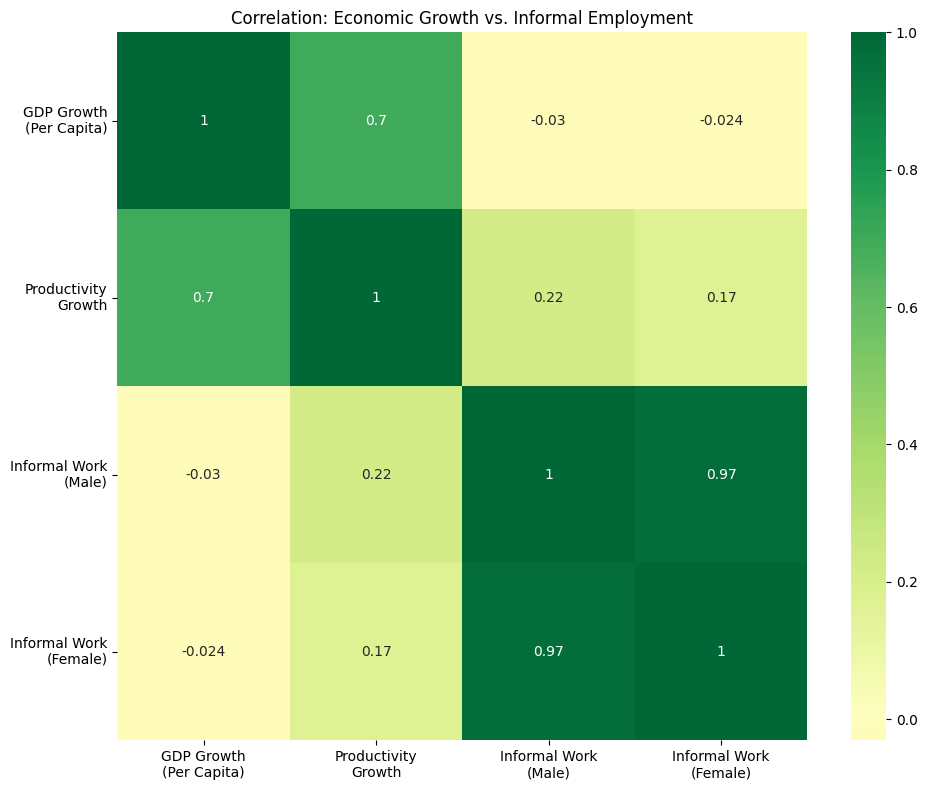

In [ ]:
#Correlation Analysis

# I'm creating a 'nickname' list so the heatmap doesn't get cut off in the PDF
short_labels = [
    'GDP Growth\n(Per Capita)',
    'Productivity\nGrowth',
    'Informal Work\n(Male)',
    'Informal Work\n(Female)'
]

# Calculating the correlation
analysis_matrix = df_clean.drop(columns=['Year']).corr(numeric_only=True)

# Plotting the heatmap
plt.figure(figsize=(10, 8)) # Adjusted size for PDF fitting
sns.heatmap(analysis_matrix,
            annot=True,
            cmap='RdYlGn',
            center=0,
            xticklabels=short_labels, # Applying my clean nicknames
            yticklabels=short_labels)

# Making sure the labels are horizontal and easy to read
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.title('Correlation: Economic Growth vs. Informal Employment')

# This line ensures nothing is 'chopped off' when saving to PDF
plt.tight_layout()
plt.show()

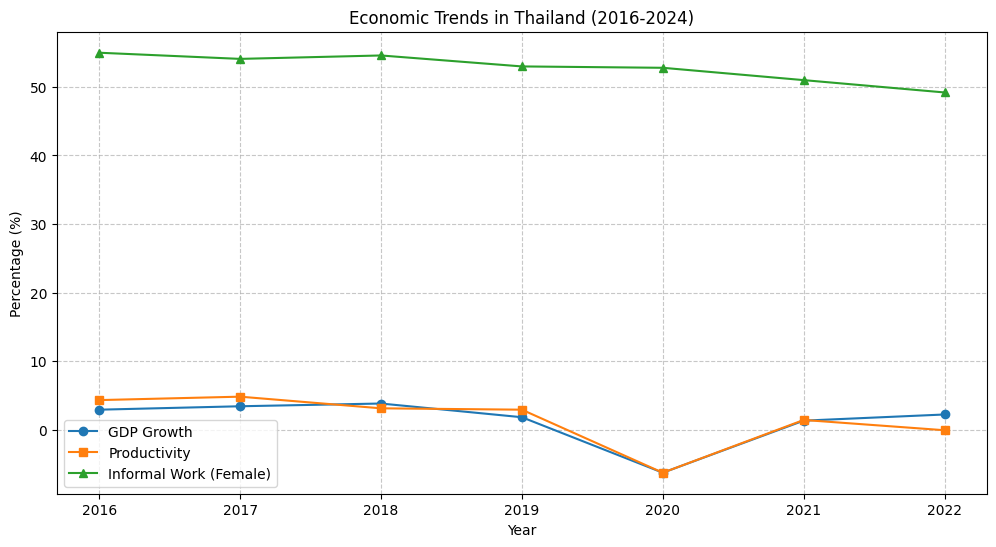

In [15]:
# Trend Analysis
# I want to see how these indicators changed over the years for a specific country.
# This helps explain the 'shocks' to the economy, like in 2020.

# Choosing a country to look at closely
target_country = 'Thailand'
country_data = df_clean[df_clean['Country'] == target_country]

plt.figure(figsize=(12, 6))

# Plotting each variable to see the timeline
plt.plot(country_data['Year'], country_data['Annual growth rate of real GDP per capita (%)'], marker='o', label='GDP Growth')
plt.plot(country_data['Year'], country_data['Annual growth rate of real GDP per employed person (%)'], marker='s', label='Productivity')
plt.plot(country_data['Year'], country_data['Proportion of informal employment in total employment, Female (%)'], marker='^', label='Informal Work (Female)')

plt.title(f'Economic Trends in {target_country} (2016-2024)')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##1. Discussion of the Dataset<br>

For this analysis, I put together four different sets of data from the UN SDG 8 (Decent Work and Economic Growth). My goal was to see how GDP, productivity, and informal work (for both male and female) actually look when you put them side-by-side from 2016 to 2024.<br>

How I set it up: The original files were a bit messy, because some had years as rows and others had countries as columns. I had to "melt" and merge them so everything lined up perfectly for every country and every year.<br>

Cleaning the data: I used a command called dropna() to clean things up. Basically, if a country didn't report their numbers for even one year, I took them out. I did this because I wanted my final results to be 100% accurate, not based on guesses. This left me with a solid list: Brunei, Indonesia, Lao PDR, Myanmar, Singapore, Thailand, and Viet Nam. <br>

##2. Relevance of the Study<br>

I chose this specific focus because SDG 8 is central to the ASEAN identity, where labor markets are often split between high-tech hubs and massive informal sectors.<br>

Understanding Vulnerability: This study is relevant because it tests whether a high proportion of informal labor, often seen as "low quality" work, actually hinders national growth in this region.<br>

Gender Analysis: By analyzing Male and Female informality as separate variables, I am able to highlight gender-based labor disparities that a general economic average would normally hide.<br>

##3. Interpretation of Results<br>

Following my Descriptive and Correlation Analysis, I have derived several key insights regarding the ASEAN economy:

###A. Productivity: The Engine of Growth
My correlation heatmap shows a strong positive correlation between GDP Growth and Productivity.<br>

What this means: It’s pretty clear that for ASEAN countries, the best way to grow isn't just to have more people working, it’s about making sure those workers are more efficient. When people get better at their jobs, the whole country gets richer.<br>

###B. The Informality Paradox<br>
I expected that having a lot of informal work would be bad for the economy (showing up as red on my map), but it wasn't. It was actually neutral (yellow).<br>

What this means: This was a bit of a surprise, because it tells me that the informal sector, like small street stalls or family farms, is actually a safety net. Especially during the 2020 pandemic, when big companies struggled, the informal sector kept people working and kept the economy from totally crashing.<br>

###C. The Gender Gap is Real<br>
When I looked at the averages, I noticed that women are in informal jobs way more often than men, especially in places like Myanmar and Lao PDR (where it’s over 90%).<br>

What this means: This is a big deal for SDG 8. It shows that even when a country is growing, women are often stuck in jobs that don't have contracts or benefits. We can't say we've reached our goals until these jobs become more formal and secure for women.<br>

###D. The Data Gap Finding<br>
The fact that I had to exclude countries like the Philippines and Malaysia due to missing reporting years is a critical finding in itself.<br>

What this means: You can't fix what you don't track. To really hit the 2030 goals, these countries need to get better at recording their labor stats so we can actually see the full picture of what’s happening in ASEAN.<br>